# Exploratory Data Analysis

## Descripción General

En este documento buscámos entender los datos que tenemos a nuestra disposición, para predecir que clientes se subscribirán a un déposito a plazos. Queremos entender la estructura del dataset y  la calidad de los datos para prepararnos para el pre-procesado.

In [1]:
!pip install jinja2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def nl():
    print('\n')


# Helper function to format tables
def show_df(df, precision=2, width="100%", percent_cols=None):
    styler = (
        df.style
        .format(precision=precision, na_rep="NaN")
        .set_table_attributes(f'style="width:{width}"')
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left"), ("padding", "6px 10px")]},
            {"selector": "td", "props": [("text-align", "left"), ("padding", "6px 10px")]},
        ])
        .hide(axis="index")
    )

    if percent_cols:
        styler = styler.format({col: "{:.2f}%" for col in percent_cols})

    display(styler)


nl()
print("Datasets:")
!ls ../data



Datasets:
bank_14.pkl             bank_competition_14.pkl


Podemos observar que tenemos dos datasets, bank_14.pkl lo usaremos para entrenar y bank_competition_14.pkl para probar.

## Carga de Data y Visión Géneral

El objetivo ahora es entender la estructura géneral de los datos y tener una idea inicial de la forma de nuestros datasets.

In [2]:
df_train = pd.read_pickle('../data/bank_14.pkl')
df_test = pd.read_pickle('../data/bank_competition_14.pkl')

nl()
print('Tamaño de train: ', str(df_train.shape))
print('Tamaño de test: ', str(df_test.shape))
print('Columnas: ', str(df_train.columns.values.tolist()))



Tamaño de train:  (11000, 17)
Tamaño de test:  (162, 16)
Columnas:  ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


La variable objetivo es **deposit**. Podemos observar que hay 16 features aparte de nuestro objetivo, tenemos 11000 datos de entrenamiento y 162 para hacer testing. Más adelante exploraremos todas las variables a mayor detalle.

## Análisis de la Variable Objetivo

Empecemos por observar la distribución de los datos.

object


Class,Count,Percentage
no,5780,52.55
yes,5220,47.45


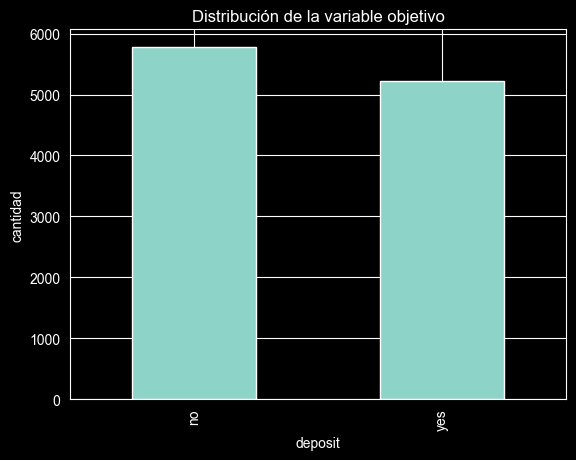

In [3]:
target = df_train['deposit'].tolist()

print(df_train['deposit'].dtype)


def label_plot(title, x, y):
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)


summary = pd.DataFrame({
    "Class": df_train['deposit'].value_counts().index,
    "Count": df_train['deposit'].value_counts().values,
    "Percentage": df_train['deposit'].value_counts(normalize=True).values * 100
})

show_df(summary)

df_train["deposit"].value_counts().plot(kind="bar")
label_plot('Distribución de la variable objetivo', 'deposit', 'cantidad')
plt.show()

La variable deposit presenta dos clases "yes" y "no", por lo que el problema es de clasificación binaria. La clase mayoritaria es "no", representando 52.54% de las instancias, mientras que "yes" representa el 47.45%. Por tanto, el conjunto de datos presenta un desbalance leve, que tendrá que tomarse en cuenta durante la evaluación de modelos.

## Esquema de Variables


In [4]:
summary = pd.DataFrame({
    "Feature": df_train.columns,
    "Semantic Type": df_train.dtypes,
    "Unique Values": df_train.nunique(dropna=True).tolist(),

})

summary = summary.sort_values("Semantic Type")

show_df(summary)

Feature,Semantic Type,Unique Values
age,int64,76
previous,int64,34
pdays,int64,472
campaign,int64,36
duration,int64,1423
balance,int64,3783
day,int64,31
month,object,12
contact,object,3
loan,object,2


Quitando deposit, tengo 16 features. 7 son números, 11 son variables de tipo object. Las variables object tienen pocos valores únicos, lo que me hace pensar que son categóricas.

Procederé a analizarlas a mayor detalle, buscando entender como se distribuyen y en cuales vale la pena indagar más a profundidad después.


### Variables Categóricas

Nos interesa saber su cardinalidad, si hay desbalances en las distribuciones, cúal es la categória dominante y si les faltan valores.

In [5]:
cat = df_train.select_dtypes(include="object")

rows = []

for col in cat.columns:
    freq = (cat[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    categories = ["NaN" if pd.isna(x) else x for x in freq.index]
    dist = [f"({catg}, {pct}%)" for catg, pct in zip(categories, freq.tolist())]

    rows.append(", ".join(dist))

summary = pd.DataFrame({
    "Feature": cat.columns,
    "n_categories": cat.nunique(dropna=True).tolist(),
    "missing_values": cat.isnull().sum().tolist(),
    "missing_values %": (cat.isnull().mean() * 100).round(2).values,
    "category_distribution_top": rows,
})

summary = summary.sort_values("n_categories", ascending=False)

show_df(summary)

Feature,n_categories,missing_values,missing_values %,category_distribution_top
job,12,174,1.58,"(management, 22.52%), (blue-collar, 17.27%), (technician, 15.97%), (admin., 11.75%), (services, 8.27%), (retired, 6.82%), (self-employed, 3.59%), (student, 3.22%), (unemployed, 3.08%), (entrepreneur, 2.88%), (housemaid, 2.45%), (NaN, 1.58%), (unknown, 0.6%)"
month,12,0,0.00,"(may, 25.27%), (aug, 13.64%), (jul, 13.59%), (jun, 10.95%), (nov, 8.45%), (apr, 8.23%), (feb, 6.94%), (oct, 3.52%), (jan, 3.11%), (sep, 2.85%), (mar, 2.46%), (dec, 0.99%)"
education,4,0,0.00,"(secondary, 49.03%), (tertiary, 33.0%), (primary, 13.48%), (unknown, 4.49%)"
poutcome,4,0,0.00,"(unknown, 74.59%), (failure, 10.98%), (success, 9.63%), (other, 4.8%)"
marital,3,340,3.09,"(married, 55.26%), (single, 30.39%), (divorced, 11.25%), (NaN, 3.09%)"
contact,3,0,0.00,"(cellular, 72.02%), (unknown, 20.99%), (telephone, 6.99%)"
default,2,0,0.00,"(no, 98.48%), (yes, 1.52%)"
housing,2,0,0.00,"(no, 52.74%), (yes, 47.26%)"
loan,2,0,0.00,"(no, 86.99%), (yes, 13.01%)"
deposit,2,0,0.00,"(no, 52.55%), (yes, 47.45%)"


Observaciones:
* _default_ tiene una distribución extremadamente concentrada en "no" (98.5%). Esto sugiere una baja variabilidad y potencialmente una utilidad predictiva limitada. No conviene eliminarla automáticamente, pero sí tener presente que aporta muy poca diversidad.
* _job_ y _marital_ tienen valores nulos: Las analizaremos a mayor profundidad para saber como tratarlas.
* _job_, _education_, _contact_ y _poutcome_ tienen "unknown" como clases. Hay que analizar su valor semántico par saber si tratarlos como información no disponible o un valor nulo, esa decir una categória o un missing imputable.
* _month_ y _job_ tienen 12 categorías diferentes, esto no es cardinalidad extrema, podemos hacer encoding categórico sin problema.
    * Aunque tengan valores con poca presencia, como "dec" en _month_ y "housemaid" en _job_, no son suficientemente pequeños como para tener que agruparlos inmediatamente.

Cabe recalcar que _poutcome_ está dominada por la categória "unknown" (74.6%), lo que nos indica que para la mayoría de observaciones no hay información concisa. Esto puede reducir su utilidad.

Basado en estos datos, clasificaría las variables de la siguiente manera:
* **Sin Incidencia Particular:** _housing_, _loan_
* **Variables Binarias Muy Desbalanceadas:** _default_
* **Variables Ambiguas ("unknown"):** _job_, _education_, _contact_, _poutcome_
* **Variables con Valores Nulos:** _job_, _marital_
* **Variables con Alta Cardinalidad:** _month_, _job_



### Variable Numéricas

Nos interesa saber la distribución de las variables, sus rangos y si tienen valores extremos.

In [6]:
num = df_train.select_dtypes(include="number")


def outlier_info_iqr(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Outliers": mask.sum(),
        "Outliers (%)": mask.mean() * 100
    }


summary = pd.DataFrame({
    "Feature": num.columns,
    "Min": [num[col].min() for col in num.columns],
    "Max": [num[col].max() for col in num.columns],
    "Range": [num[col].max() - num[col].min() for col in num.columns],
    "STD": [num[col].std() for col in num.columns],
    "Skewness": [num[col].skew() for col in num.columns],
    "Kurtosis": [num[col].kurtosis() for col in num.columns],
    "Mean": [num[col].mean() for col in num.columns],
    "Median": [num[col].median() for col in num.columns],
})

show_df(summary)

outlier_table = pd.DataFrame([
    {"Feature": col, **outlier_info_iqr(num[col])}
    for col in num.columns
])

show_df(outlier_table.sort_values("Outliers (%)", ascending=False))

Feature,Min,Max,Range,STD,Skewness,Kurtosis,Mean,Median
age,18,95,77,11.94,0.86,0.62,41.25,39.00
balance,-6847,81204,88051,3217.40,8.25,128.57,1529.14,549.50
day,1,31,30,8.42,0.11,-1.06,15.66,15.00
duration,2,3881,3879,347.52,2.14,7.29,372.52,255.00
campaign,1,63,62,2.72,5.57,57.87,2.51,2.00
pdays,-1,854,855,108.78,2.46,6.90,51.31,-1.00
previous,0,58,58,2.28,7.43,109.01,0.83,0.00


Feature,Q1,Q3,IQR,Lower bound,Upper bound,Outliers,Outliers (%)
pdays,-1.00,20.25,21.25,-32.88,52.12,2711,24.65
previous,0.00,1.00,1.00,-1.50,2.50,1234,11.22
balance,122.75,1711.00,1588.25,-2259.62,4093.38,1043,9.48
duration,138.00,498.00,360.00,-402.00,1038.00,620,5.64
campaign,1.00,3.00,2.00,-2.00,6.00,589,5.35
age,32.00,49.00,17.00,6.50,74.50,171,1.55
day,8.00,22.00,14.00,-13.00,43.00,0,0.00


Observaciones:
* Las variables numéricas no están en la misma escala. _balance_ tiene un rango y desviación mayor que el resto. _campaign_, _previous_ o _day_ tienen escalas más reducidas. Esto sugiere que, si se utilizan modelos sensibles a distancias o magnitudes, será necesario aplicar escalado.
* _duration_, _balance_, _previous_ y _campaign_ muestran una asimetría positiva y una curtosis elevada.
    * En _previous_ y _campaign_ sugiere que la mayoría de observaciones se concentran en valores bajos.
    * _duration_ presenta estas características de forma menos extrema que las otras. Aun así, la diferencia entre media y mediana y su porcentaje de outliers indican que conviene tenerla en cuenta como variable potencialmente problemática.
* _balance_ es la variable numérica más extrema desde el punto de vista distributivo. Podemos observar una distribución sesgada a la derecha con presencia de valores altos poco frecuentes.
* _pdays_ requiere una interpretación diferente. Esta variable no debe interpretarse como una numérica ordinaria, ya que contiene el valor -1, que actúa como código especial. Por tanto, parte de su comportamiento estadístico puede deberse a esa codificación.
* _age_ muestra una distribución relativamente estable en comparación con el resto. Aunque presenta sesgo positivo y valores extremos según el IQR, de igual manera su comportamiento es mucho más moderado.
* _day_ es la variable más regular del conjunto. Tiene asimetría baja, curtosis negativa y no presenta outliers, no parece plantear problemas a nivel distributivo.

Las variables que requieren mayor atención son _balance_, _previous_, _campaign_, _duration_ y especialmente _pdays_, ya sea por su asimetría, por sus valores extremos o semántica especial. En cambio, _age_ y _day_ parecen menos problemáticas desde el punto de vista estructural.

## Variables Problématicas

Ahora procederemos a analizar las variables ambiguas o próblematicas para definir que se puede hacer con ellas.

## Correlación de Los Predictores con La Variable Objetivo

Después de haber hecho el barrido de las variables, nos conviene saber realmente que variables influencian la variable objetivo _deposit_. Para esto...
